In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q timm torch torchvision scikit-learn matplotlib pandas tqdm

In [3]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

import timm

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [5]:
ROOT = "/content/drive/MyDrive/Deepfake_Project/Processed"

TRAIN_CSV = os.path.join(ROOT, "train.csv")
VAL_CSV = os.path.join(ROOT, "val.csv")
TEST_CSV = os.path.join(ROOT, "test.csv")

In [6]:
train_df = pd.read_csv(TRAIN_CSV)

val_df = pd.read_csv(VAL_CSV)

test_df = pd.read_csv(TEST_CSV)

print(train_df.head())

print()

print(len(train_df))

print(len(val_df))

print(len(test_df))

                                               image  label
0  /content/drive/MyDrive/Deepfake_Project/Proces...      0
1  /content/drive/MyDrive/Deepfake_Project/Proces...      0
2  /content/drive/MyDrive/Deepfake_Project/Proces...      0
3  /content/drive/MyDrive/Deepfake_Project/Proces...      0
4  /content/drive/MyDrive/Deepfake_Project/Proces...      0

10474
1679
1682


# Image Transformations

In [7]:
train_transform = transforms.Compose([

    transforms.Resize((299,299)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )

])

val_transform = transforms.Compose([

    transforms.Resize((299,299)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5]*3,
        std=[0.5]*3
    )

])

In [8]:
class DeepfakeDataset(Dataset):

    def __init__(self, dataframe, transform):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        image = Image.open(

            self.df.iloc[index]["image"]

        ).convert("RGB")

        label = self.df.iloc[index]["label"]

        image = self.transform(image)

        return image, label

In [9]:
train_dataset = DeepfakeDataset(

    train_df,

    train_transform

)

val_dataset = DeepfakeDataset(

    val_df,

    val_transform

)

test_dataset = DeepfakeDataset(

    test_df,

    val_transform

)

# Create DataLoader

In [10]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    num_workers=2

)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2

)

In [11]:
images,labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 299, 299])
torch.Size([32])


# Create Xception Model

In [12]:
import timm
import torch.nn as nn

model = timm.create_model(
    "xception",
    pretrained=True,
    num_classes=2
)

model = model.to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Xception(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU(inplace=True)
  (block1): Block(
    (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (rep): Sequential(
      (0): SeparableConv2d(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [13]:
dummy = torch.randn(1,3,299,299).to(device)

output = model(dummy)

print(output.shape)

torch.Size([1, 2])


# Loss Function

In [14]:
criterion = nn.CrossEntropyLoss()

# Optimizer

In [15]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-5

)

# Learning Rate Scheduler

In [16]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2

)

# Training Function

In [17]:
def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion):

    model.train()

    running_loss = 0

    predictions = []

    labels = []

    for images,targets in tqdm(loader):

        images = images.to(device)

        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        predictions.extend(
            preds.cpu().numpy()
        )

        labels.extend(
            targets.cpu().numpy()
        )

    epoch_loss = running_loss/len(loader)

    epoch_acc = accuracy_score(
        labels,
        predictions
    )

    return epoch_loss,epoch_acc

# validation Function

In [18]:
@torch.no_grad()

def validate(model,
             loader,
             criterion):

    model.eval()

    running_loss = 0

    predictions = []

    labels = []

    for images,targets in loader:

        images = images.to(device)

        targets = targets.to(device)

        outputs = model(images)

        loss = criterion(outputs,targets)

        running_loss += loss.item()

        preds = outputs.argmax(1)

        predictions.extend(
            preds.cpu().numpy()
        )

        labels.extend(
            targets.cpu().numpy()
        )

    epoch_loss = running_loss/len(loader)

    epoch_acc = accuracy_score(
        labels,
        predictions
    )

    return epoch_loss,epoch_acc

* Variables

In [19]:
best_loss = np.inf

train_losses = []

val_losses = []

train_accs = []

val_accs = []

best_model = None

In [20]:
MODEL_DIR = "/content/drive/MyDrive/Deepfake_Project/Models"

os.makedirs(MODEL_DIR,exist_ok=True)

# Model train

In [21]:
EPOCHS = 3

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss,train_acc = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion

    )

    val_loss,val_acc = validate(

        model,

        val_loader,

        criterion

    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accs.append(train_acc)

    val_accs.append(val_acc)

    print()

    print("Train Loss :",train_loss)

    print("Train Acc :",train_acc)

    print()

    print("Val Loss :",val_loss)

    print("Val Acc :",val_acc)

    if val_loss < best_loss:

        best_loss = val_loss

        best_model = copy.deepcopy(model.state_dict())

        torch.save(

            best_model,

            os.path.join(

                MODEL_DIR,

                "xception_best.pth"

            )

        )

        print()

        print("Best Model Saved")


Epoch 1/3


100%|██████████| 328/328 [35:00<00:00,  6.40s/it]



Train Loss : 0.15365529330674468
Train Acc : 0.9206606835974794

Val Loss : 0.16107422561178264
Val Acc : 0.8844550327575939

Best Model Saved

Epoch 2/3


100%|██████████| 328/328 [05:30<00:00,  1.01s/it]



Train Loss : 0.06257473561833272
Train Acc : 0.9611418751193431

Val Loss : 0.1578275318779389
Val Acc : 0.8862418106015485

Best Model Saved

Epoch 3/3


100%|██████████| 328/328 [05:56<00:00,  1.09s/it]



Train Loss : 0.05523281840134764
Train Acc : 0.9647699064349818

Val Loss : 0.16024529566199552
Val Acc : 0.8832638475282907


# Now evaluation

In [22]:
import os
import torch

MODEL_PATH = "/content/drive/MyDrive/Deepfake_Project/Models/xception_best.pth"

model.load_state_dict(torch.load(MODEL_PATH))

model.eval()

print("Best Model Loaded")

Best Model Loaded


In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

true_labels = []
predictions = []
probabilities = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        true_labels.extend(labels.numpy())

        predictions.extend(preds.cpu().numpy())

        probabilities.extend(probs[:,1].cpu().numpy())

100%|██████████| 53/53 [04:53<00:00,  5.54s/it]


* Calculate Metrics

In [24]:
accuracy = accuracy_score(
    true_labels,
    predictions
)

precision = precision_score(
    true_labels,
    predictions
)

recall = recall_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

auc = roc_auc_score(
    true_labels,
    probabilities
)

print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 Score :",f1)

print("ROC AUC :",auc)

Accuracy : 0.9577883472057075
Precision : 0.9873417721518988
Recall : 0.9274673008323424
F1 Score : 0.9564684242795831
ROC AUC : 0.9968166824783926


* Classification report

In [25]:
from sklearn.metrics import classification_report

print(

    classification_report(

        true_labels,

        predictions,

        target_names=["Real","Fake"]

    )

)

              precision    recall  f1-score   support

        Real       0.93      0.99      0.96       841
        Fake       0.99      0.93      0.96       841

    accuracy                           0.96      1682
   macro avg       0.96      0.96      0.96      1682
weighted avg       0.96      0.96      0.96      1682



# Confusion Matrix

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    true_labels,

    predictions

)

print(cm)

[[831  10]
 [ 61 780]]


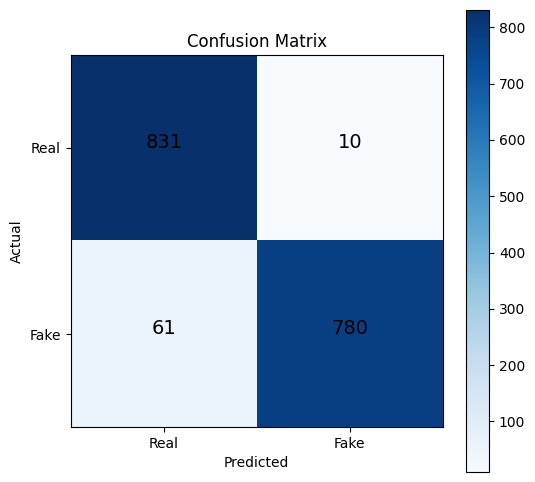

In [27]:
plt.figure(figsize=(6,6))

plt.imshow(cm,cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Real","Fake"])

plt.yticks([0,1],["Real","Fake"])

for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i,j],

            ha="center",

            fontsize=14

        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ROC Curve

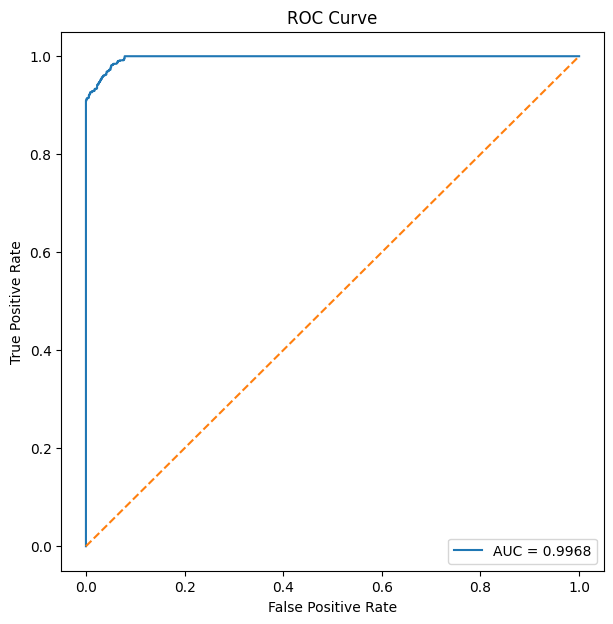

In [28]:
from sklearn.metrics import roc_curve

fpr,tpr,_ = roc_curve(

    true_labels,

    probabilities

)

plt.figure(figsize=(7,7))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Training Curves

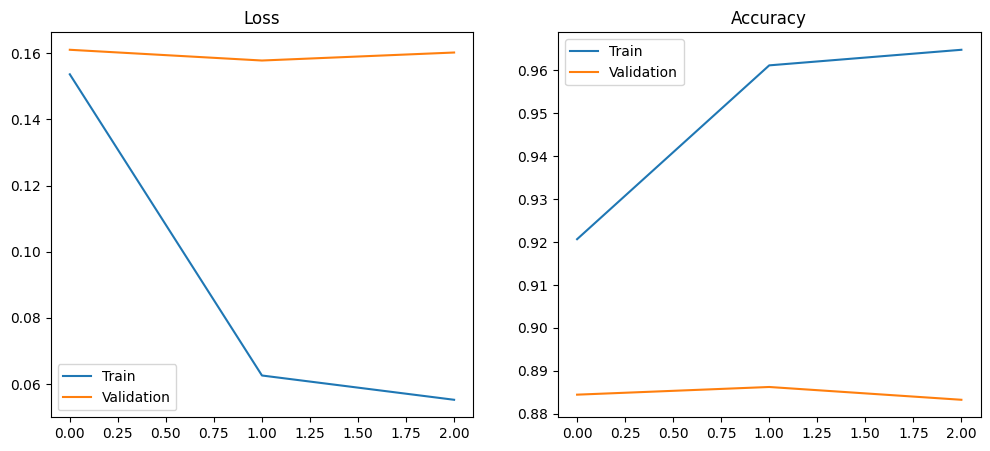

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(train_losses,label="Train")

plt.plot(val_losses,label="Validation")

plt.title("Loss")

plt.legend()

plt.subplot(1,2,2)

plt.plot(train_accs,label="Train")

plt.plot(val_accs,label="Validation")

plt.title("Accuracy")

plt.legend()

plt.show()

In [30]:
metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC_AUC"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        auc

    ]

})

RESULT_DIR = "/content/drive/MyDrive/Deepfake_Project/Results"

os.makedirs(RESULT_DIR,exist_ok=True)

metrics.to_csv(

    os.path.join(

        RESULT_DIR,

        "metrics_xception.csv"

    ),

    index=False

)

metrics

,Metric,Value
0,Accuracy,0.957788
1,Precision,0.987342
2,Recall,0.927467
3,F1,0.956468
4,ROC_AUC,0.996817


In [31]:
plt.figure(figsize=(7,7))

plt.plot(fpr,tpr,label=f"AUC={auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.legend()

plt.savefig(

    os.path.join(

        RESULT_DIR,

        "roc_xception.png"

    )

)

plt.close()